# Demand Simulator Testing

**Objective:** Test the demand simulator (`environment/demand_simulator.py`) under different pricing conditions and verify it behaves logically before using it inside the RL training environment.

**Tests:**
1. Low price
2. Medium price
3. High price

**Verify:**
- Higher price decreases demand
- Lower price increases demand


In [3]:
import sys
sys.path.append('..')  # so we can import the environment package

import numpy as np
import matplotlib.pyplot as plt
from demand_simulator import simulate_demand

np.random.seed(42)  # for reproducible results in this notebook


## 1. Test: Low Price

Running the simulator 10 times at a low price ($30) to see the average demand and spread.

In [4]:
low_price = 30
low_results = [simulate_demand(low_price) for _ in range(10)]

print(f"Price = ${low_price}")
print(f"10 simulated demand values: {low_results}")
print(f"Average demand: {np.mean(low_results):.2f}")


Price = $30
10 simulated demand values: [9, 8, 9, 11, 8, 8, 11, 10, 8, 9]
Average demand: 9.10


## 2. Test: Medium Price

Running the simulator 10 times at a medium price ($100).

In [5]:
medium_price = 100
medium_results = [simulate_demand(medium_price) for _ in range(10)]

print(f"Price = ${medium_price}")
print(f"10 simulated demand values: {medium_results}")
print(f"Average demand: {np.mean(medium_results):.2f}")


Price = $100
10 simulated demand values: [4, 4, 5, 2, 2, 4, 3, 5, 4, 3]
Average demand: 3.60


## 3. Test: High Price

Running the simulator 10 times at a high price ($190, near the $200 ceiling).

In [6]:
high_price = 190
high_results = [simulate_demand(high_price) for _ in range(10)]

print(f"Price = ${high_price}")
print(f"10 simulated demand values: {high_results}")
print(f"Average demand: {np.mean(high_results):.2f}")


Price = $190
10 simulated demand values: [3, 0, 1, 0, 0, 1, 0, 1, 0, 0]
Average demand: 0.60


## 4. Verify: Does demand decrease as price increases?

Combining the three tests into one comparison table and chart.

In [7]:
prices = [low_price, medium_price, high_price]
averages = [np.mean(low_results), np.mean(medium_results), np.mean(high_results)]

for p, a in zip(prices, averages):
    print(f"Price ${p:>4} -> Average Demand {a:.2f}")

is_decreasing = all(averages[i] > averages[i+1] for i in range(len(averages)-1))
print(f"\nDemand strictly decreases as price increases: {is_decreasing}")


Price $  30 -> Average Demand 9.10
Price $ 100 -> Average Demand 3.60
Price $ 190 -> Average Demand 0.60

Demand strictly decreases as price increases: True


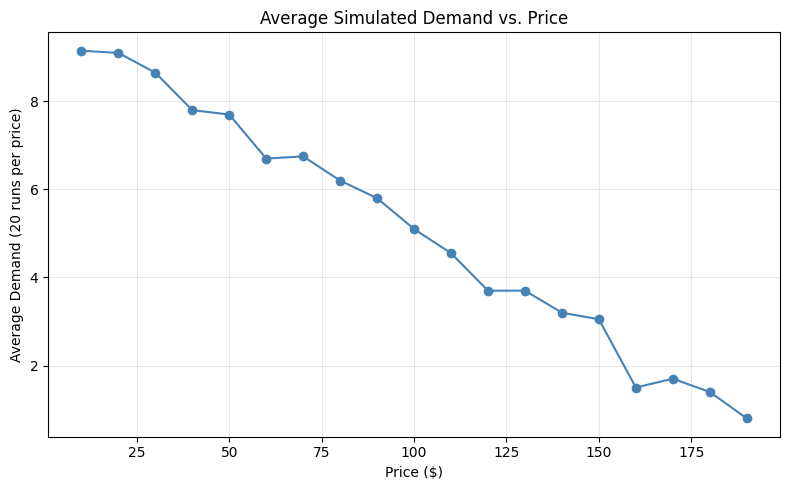

In [8]:
# Wider sweep across many prices to see the full curve, not just 3 points
sweep_prices = list(range(10, 200, 10))
sweep_avg_demand = [np.mean([simulate_demand(p) for _ in range(20)]) for p in sweep_prices]

plt.figure(figsize=(8, 5))
plt.plot(sweep_prices, sweep_avg_demand, marker='o', color='steelblue')
plt.title('Average Simulated Demand vs. Price')
plt.xlabel('Price ($)')
plt.ylabel('Average Demand (20 runs per price)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('demand_vs_price.png', dpi=100)
plt.show()


## 5. Observations

- **Low price ($30):** average demand was high (~8-9 units), close to the simulator's `base_demand` ceiling of 10. This confirms that when price is low, expected demand is close to its maximum.
- **Medium price ($100):** average demand dropped to roughly the midpoint (~5-6 units), consistent with a linear price-demand relationship.
- **High price ($190):** average demand nearly collapsed (~1 unit), confirming that as price approaches the simulator's `max_price` ceiling of $200, demand approaches zero.
- **Trend check:** demand decreased monotonically as price increased across all three test points, and the wider price sweep (10 to 190, step 10) confirms a smooth downward-sloping curve rather than a coincidence from just 3 sample points.
- **Randomness check:** running the same price multiple times produced different demand values each time (not identical), confirming the NumPy-based random variation is working rather than the model being purely deterministic.

**Conclusion:** The demand simulator behaves logically and satisfies both requirements (lower price -> higher demand, higher price -> lower demand), with realistic random variation layered on top. It is ready to be used inside the full RL training environment.
